In [13]:
"""
Transmission Cluster Size Model
================================
Zero-Truncated Negative Binomial GLM (log link, NB2 parameterisation).

Model
-----
    log E[Y_i | Y_i >= 1] = offset_i + beta @ X_i

    offset_i = log(wn_prop_sequenced_i)

    X_i includes:
        - simd_quintile_std          (continuous; within-cluster socioeconomic mixing)
        - C(epoch)                   (dummy-coded; ref = Delta)
        - C(simd_quintile_mode)      (dummy-coded; ref = Q3)
        - C(epoch) : C(simd_q)       (full interaction; 4 × 4 = 16 terms)

Rationale (from EDA)
---------------------
    - Dispersion ratio ~176 → Negative Binomial over Poisson
    - Singleton rate strongly correlated with low sequencing (r = -0.82)
      → singletons are artefactual → zero-truncated model, exclude singletons
    - log(wn_prop_sequenced) used as offset to avoid dominating regression
    - Epoch × SIMD quintile mode interaction observed in EDA (§9)
    - simd_quintile_std carries independent signal after partialling out mode
"""

import itertools
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import patsy
import seaborn as sns
import statsmodels.api as sm
from scipy.special import betainc, gammaln
from scipy.stats import norm, probplot
from statsmodels.base.model import GenericLikelihoodModel

from analysis.utils import data, style

warnings.filterwarnings("ignore")

style.set_theme()

EPOCHS_ORDERED = [lb for lb, _, _ in data.VOC_EPOCHS]
TIME_SPLINE_DF = 4
# f" + cr(t_spline, df={TIME_SPLINE_DF})"

In [18]:
# ── 1. Data preparation ───────────────────────────────────────────────────────

def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construct modelling columns.

    Parameters
    ----------
    df : full cluster-level DataFrame from build_cluster_regression_frame()

    Returns
    -------
    ns : modelling-ready DataFrame (one row per non-singleton cluster)
    """
    df = df.dropna(subset=[
        "n_sequences", "wn_prop_sequenced", "wn_mid_date",
        "simd_quintile_mode", "simd_quintile_std", "epoch"
    ]).copy()


    # Offset: log sequencing proportion
    df["log_seq_prop"] = np.log(df["wn_prop_sequenced"])

    t = pd.to_datetime(df["wn_mid_date"])
    origin = t.min()
    days = (t - origin).dt.days.astype(float).to_numpy()
    # Normalise to [0, 1]. The cr() basis is invariant to monotone scaling,
    # but keeping the predictor in [0, 1] markedly improves IRLS
    # conditioning alongside unit-SD standardised deprivation and 0/1 VOC
    # dummies — an unnormalised ``days`` column (values up to ~930) made
    # the NB fits oscillate and blow up memory at df ≥ 5.
    span = float(days.max() - days.min()) or 1.0
    df["t_spline"] = (days - days.min()) / span

    # Ordered categoricals — reference levels chosen explicitly
    df["epoch"] = pd.Categorical(
        df["epoch"],
        categories=EPOCHS_ORDERED,
        ordered=True,
    )
    df["simd_q"] = pd.Categorical(
        df["simd_quintile_mode"].astype(int),
        categories=[1, 2, 3, 4, 5],
        ordered=True,
    )

    # Sanity checks
    assert (df["n_sequences"] >= 2).all(), "Non-singleton filter failed: found size-1 clusters"
    assert df["log_seq_prop"].notna().all(), "NaN offset values — check wn_prop_sequenced > 0"

    print(f"Modelling sample: {len(ns):,} non-singleton clusters")
    print(f"  Epoch counts:\n{ns['epoch'].value_counts().sort_index().to_string()}")
    print(f"  SIMD quintile counts:\n{ns['simd_q'].value_counts().sort_index().to_string()}")

    return ns


# ── 2. Zero-Truncated Negative Binomial ──────────────────────────────────────

class ZeroTruncatedNegBin(GenericLikelihoodModel):
    """
    Zero-Truncated Negative Binomial GLM (NB2, log link).

    Conditions the NB likelihood on Y >= 1:

        log P(Y=y | Y>=1) = log P(Y=y) - log(1 - P(Y=0))

    where P(Y=y) is the standard NB2 PMF with mean mu and overdispersion
    alpha (var = mu + alpha * mu^2).

    The last element of `params` is log(alpha), estimated jointly with the
    regression coefficients to keep alpha strictly positive.

    Parameters
    ----------
    endog  : 1-D array of cluster sizes (must all be >= 1)
    exog   : design matrix (intercept included)
    offset : 1-D array of log(wn_prop_sequenced), added to linear predictor
    """

    def __init__(self, endog, exog, offset=None, **kwargs):
        super().__init__(endog, exog, **kwargs)
        self.offset = (
            np.zeros(len(endog)) if offset is None else np.asarray(offset, dtype=float)
        )

    def nloglikeobs(self, params):
        log_alpha = params[-1]
        alpha     = np.exp(log_alpha)   # strictly positive
        beta      = params[:-1]

        eta = self.exog @ beta + self.offset
        mu  = np.exp(np.clip(eta, -20, 20))  # guard against overflow

        # NB2: r = 1/alpha, p = r / (r + mu)
        r = 1.0 / alpha
        p = r / (r + mu)

        y = self.endog

        # log P(Y = y) — NB PMF
        log_py = (
            gammaln(y + r) - gammaln(r) - gammaln(y + 1)
            + r * np.log(p)
            + y * np.log1p(-p)
        )

        # log P(Y = 0) = r * log(p)
        log_p0 = r * np.log(p)

        # Truncated log-likelihood: log P(Y=y | Y>=1)
        log_trunc_py = log_py - np.log1p(-np.exp(log_p0))

        return -log_trunc_py

    def fit(self, start_params=None, method="lbfgs", maxiter=1_000, **kwargs):
        if start_params is None:
            # Warm-start betas from OLS on log(y); initialise log(alpha) = log(0.5)
            ols     = sm.OLS(np.log(self.endog), self.exog).fit()
            start_params = np.append(ols.params, np.log(0.5))
        return super().fit(
            start_params=start_params,
            method=method,
            maxiter=maxiter,
            **kwargs,
        )


# ── 3. Build design matrix ────────────────────────────────────────────────────

FORMULA = (
    "n_sequences ~ simd_quintile_std"
    " + C(epoch, Treatment('Delta'))"
    " * C(simd_q, Treatment(3))"
)


def build_design_matrix(df: pd.DataFrame):
    """Return (y_array, X_dataframe) using the model formula."""
    y_df, X_df = patsy.dmatrices(FORMULA, data=df, return_type="dataframe")
    return np.asarray(y_df).flatten(), X_df


# ── 4. Fit ────────────────────────────────────────────────────────────────────

def fit_model(ns: pd.DataFrame):
    y, X_df = build_design_matrix(ns)
    offset   = ns["log_seq_prop"].values

    model  = ZeroTruncatedNegBin(endog=y, exog=np.asarray(X_df), offset=offset)
    result = model.fit(disp=False)

    xnames = list(X_df.columns) + ["log(alpha)"]
    print(result.summary(xname=xnames))

    alpha_hat = np.exp(result.params[-1])
    print(f"\nEstimated overdispersion  α = {alpha_hat:.4f}")
    print(f"  (α → 0 ≈ Poisson;  α >> 0 = strong overdispersion)")

    return result, X_df


# ── 5. Truncated-NB helpers ───────────────────────────────────────────────────

def _nb2_zero_prob(mu: np.ndarray, alpha: float) -> np.ndarray:
    """Return P(Y=0) for an NB2 random variable with mean ``mu``."""
    mu = np.asarray(mu, dtype=float)
    r  = 1.0 / alpha
    p  = r / (r + mu)
    return p ** r


def trunc_corrected_mean(mu: np.ndarray, alpha: float) -> np.ndarray:
    """Return E[Y | Y >= 1] under NB2."""
    mu = np.asarray(mu, dtype=float)
    p0 = _nb2_zero_prob(mu, alpha)
    q  = np.clip(1.0 - p0, np.finfo(float).eps, 1.0)
    return mu / q


def trunc_corrected_variance(mu: np.ndarray, alpha: float) -> np.ndarray:
    """Return Var[Y | Y >= 1] under NB2."""
    mu = np.asarray(mu, dtype=float)
    p0 = _nb2_zero_prob(mu, alpha)
    q  = np.clip(1.0 - p0, np.finfo(float).eps, 1.0)
    var_nb = mu + alpha * mu ** 2
    second_moment_nb = var_nb + mu ** 2
    trunc_var = second_moment_nb / q - (mu / q) ** 2
    return np.maximum(trunc_var, np.finfo(float).eps)


def trunc_corrected_cdf(y: np.ndarray, mu: np.ndarray, alpha: float) -> np.ndarray:
    """Return P(Y <= y | Y >= 1) under NB2."""
    y, mu = np.broadcast_arrays(np.asarray(y, dtype=int), np.asarray(mu, dtype=float))
    r  = 1.0 / alpha
    p  = r / (r + mu)
    p0 = p ** r
    q  = np.clip(1.0 - p0, np.finfo(float).eps, 1.0)

    out = np.zeros_like(mu, dtype=float)
    valid = y >= 1
    if np.any(valid):
        base_cdf = betainc(r, y[valid] + 1, p[valid])
        out[valid] = (base_cdf - p0[valid]) / q[valid]

    return np.clip(out, 0.0, 1.0)


# ── 6. Marginal effects plot ──────────────────────────────────────────────────

def plot_marginal_effects(ns: pd.DataFrame, result):
    """
    Predicted cluster size on a single axis with SIMD quintiles
    nested within each epoch group,
    holding simd_quintile_std at its median and
    wn_prop_sequenced at its median (reference offset).
    """
    alpha_hat      = np.exp(result.params[-1])
    median_std     = ns["simd_quintile_std"].median()
    median_seq     = ns["wn_prop_sequenced"].median()
    log_offset_ref = np.log(median_seq)

    # Prediction grid
    records = [
        {
            "epoch": ep,
            "simd_q": sq,
            "simd_quintile_std": median_std,
            "n_sequences": 1,          # dummy endog for patsy
        }
        for ep, sq in itertools.product(EPOCHS_ORDERED, [1, 2, 3, 4, 5])
    ]
    grid = pd.DataFrame(records)
    grid["epoch"]  = pd.Categorical(grid["epoch"],  categories=EPOCHS_ORDERED, ordered=True)
    grid["simd_q"] = pd.Categorical(grid["simd_q"], categories=[1, 2, 3, 4, 5], ordered=True)

    _, X_pred = patsy.dmatrices(FORMULA, data=grid, return_type="dataframe")

    eta_pred  = np.asarray(X_pred) @ result.params[:-1] + log_offset_ref
    mu_pred   = np.exp(eta_pred)
    pred_mean = trunc_corrected_mean(mu_pred, alpha_hat)
    grid["pred_mean"] = pred_mean

    # ── 95 % delta-method confidence intervals ────────────────────────────────
    cov     = result.cov_params()[:-1, :-1]   # exclude log(alpha) row/col
    X_p     = np.asarray(X_pred)
    se_eta  = np.sqrt(np.einsum("ij,jk,ik->i", X_p, cov, X_p))
    eta_lo  = eta_pred - 1.96 * se_eta
    eta_hi  = eta_pred + 1.96 * se_eta
    grid["pred_lo"] = trunc_corrected_mean(np.exp(eta_lo), alpha_hat)
    grid["pred_hi"] = trunc_corrected_mean(np.exp(eta_hi), alpha_hat)

    # ── Plot ──────────────────────────────────────────────────────────────────
    simd_levels = [1, 2, 3, 4, 5]
    simd_hatches = ["", "//", "xx", "..", "\\\\"]
    simd_palette = dict(zip(simd_levels, sns.color_palette("YlOrBr", len(simd_levels))))

    fig, ax = style.new_figure(width="double", height_in=4)

    group_gap = 1.5
    group_width = len(simd_levels) + group_gap
    epoch_centers = []
    xtick_positions = []
    xtick_labels = []

    for epoch_idx, ep in enumerate(EPOCHS_ORDERED):
        sub = (
            grid[grid["epoch"] == ep]
            .assign(simd_q_num=lambda df: df["simd_q"].astype(int))
            .set_index("simd_q_num")
            .loc[simd_levels]
            .reset_index()
        )
        xpos = epoch_idx * group_width + np.arange(len(simd_levels))
        epoch_centers.append(xpos.mean())
        xtick_positions.extend(xpos)
        xtick_labels.extend([f"{sq}" for sq in simd_levels])

        for bar_idx, sq in enumerate(simd_levels):
            row = sub.iloc[bar_idx]
            ax.bar(
                xpos[bar_idx],
                row["pred_mean"],
                width=0.75,
                color=simd_palette[sq],
                hatch=simd_hatches[bar_idx],
                edgecolor="black",
                linewidth=0.8,
                alpha=0.9,
            )
            ax.errorbar(
                xpos[bar_idx],
                row["pred_mean"],
                yerr=np.array([
                    [row["pred_mean"] - row["pred_lo"]],
                    [row["pred_hi"]   - row["pred_mean"]],
                ], dtype=float),
                fmt="none",
                color="black",
                capsize=3,
                lw=1.1,
            )

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlabel("Neighbourhood deprivation quintile")
    ax.set_ylabel("Predicted mean cluster size\n(truncation-corrected, 95% CI)")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.tick_params(axis="x", length=0)

    for center, ep in zip(epoch_centers, EPOCHS_ORDERED):
        ax.text(
            center,
            -0.16,
            ep,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontweight="bold",
        )

    fig.suptitle(
        "Predicted cluster size by SIMD quintile across epochs\n"
        f"(SIMD std held at median = {median_std:.2f};  "
        f"sequencing coverage at median = {median_seq:.2f})",
        fontweight="bold", y=1.02,
    )
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    plt.savefig("figures/marginal_effects.png", dpi=600, bbox_inches="tight")
    plt.show()
    print("Marginal effects plot saved.")


# ── 7. Coefficient forest plot ────────────────────────────────────────────────

FOREST_EPOCHS = [ep for ep in EPOCHS_ORDERED if ep != "Delta"]
FOREST_SIMD_LEVELS = [sq for sq in [1, 2, 3, 4, 5] if sq != 3]


def _term_level(term: str):
    return term.split("[T.", 1)[1].rstrip("]")


def _format_forest_term(term: str) -> str:
    if term == "simd_quintile_std":
        return "Within-cluster SIMD mixing (std.)"

    if ":" in term:
        epoch_term, simd_term = term.split(":")
        return f"{_term_level(epoch_term)} × SIMD Q{_term_level(simd_term)}"

    if term.startswith("C(epoch"):
        return f"Epoch: {_term_level(term)}"

    if term.startswith("C(simd_q"):
        return f"SIMD quintile: Q{_term_level(term)}"

    return term


def _forest_term_order(term: str):
    if term.startswith("C(epoch") and ":" not in term:
        return (0, FOREST_EPOCHS.index(_term_level(term)), 0)

    if term.startswith("C(simd_q") and ":" not in term:
        return (1, FOREST_SIMD_LEVELS.index(int(_term_level(term))), 0)

    if ":" in term:
        epoch_term, simd_term = term.split(":")
        return (
            2,
            FOREST_EPOCHS.index(_term_level(epoch_term)),
            FOREST_SIMD_LEVELS.index(int(_term_level(simd_term))),
        )

    if term == "simd_quintile_std":
        return (3, 0, 0)

    return (4, term, 0)


def plot_forest(result, X_df: pd.DataFrame):
    """
    Forest plot of all coefficients (excluding intercept and log(alpha)).
    Useful for quickly scanning effect sizes and significance.
    """
    coef_names = list(X_df.columns)
    coefs = result.params[:-1]         # drop log(alpha)
    cis   = result.conf_int()[:-1]

    # Drop intercept for readability
    mask  = np.array(coef_names) != "Intercept"
    names = np.array(coef_names)[mask]
    c     = coefs[mask]
    lo    = cis[mask, 0]
    hi    = cis[mask, 1]

    order = sorted(range(len(names)), key=lambda idx: _forest_term_order(names[idx]))
    names = names[order]
    c, lo, hi = c[order], lo[order], hi[order]
    display_names = [_format_forest_term(name) for name in names]

    fig, ax = style.new_figure(width="double", height_in=style.FIG_WIDTHS_IN["double"])

    y = np.arange(len(display_names))
    ax.errorbar(c, y, xerr=[c - lo, hi - c],
                fmt="o", color="steelblue", capsize=3, lw=1.2, ms=4)
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Null (β=0)")

    section_breaks = [
        len(FOREST_EPOCHS),
        len(FOREST_EPOCHS) + len(FOREST_SIMD_LEVELS),
        len(FOREST_EPOCHS) + len(FOREST_SIMD_LEVELS) + len(FOREST_EPOCHS) * len(FOREST_SIMD_LEVELS),
        len(FOREST_EPOCHS) + len(FOREST_SIMD_LEVELS) + len(FOREST_EPOCHS) * len(FOREST_SIMD_LEVELS) + 1,
    ]
    for cut in section_breaks[:-1]:
        ax.axhline(cut - 0.5, color="0.85", lw=0.8, zorder=0)

    ax.set_yticks(y)
    ax.set_yticklabels(display_names)
    ax.invert_yaxis()
    ax.set_xlabel("Coefficient (log scale)")
    ax.set_title("Model coefficients — ZTNB GLM (95% CI; refs: Delta epoch, SIMD Q3)",
                 fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("figures/forest_plot.png", dpi=600, bbox_inches="tight")
    plt.show()
    print("Forest plot saved.")


# ── 8. Diagnostics ────────────────────────────────────────────────────────────

def plot_diagnostics(ns: pd.DataFrame, result, X_df: pd.DataFrame, seed: int = 42):
    """
    Diagnostics matched to the fitted zero-truncated NB model:
        (a) truncated Pearson residuals vs fitted truncated mean
        (b) QQ plot of Dunn-Smyth residuals from the truncated NB CDF

    Parameters
    ----------
    seed : int
        Random seed used for the Dunn-Smyth residual jitter so the plot is
        reproducible across runs.
    """

    alpha_hat = np.exp(result.params[-1])
    eta_fit   = np.asarray(X_df) @ result.params[:-1] + ns["log_seq_prop"].values
    mu_fit    = np.exp(eta_fit)
    y_obs     = ns["n_sequences"].to_numpy()

    fitted_mean = trunc_corrected_mean(mu_fit, alpha_hat)
    fitted_var  = trunc_corrected_variance(mu_fit, alpha_hat)
    pearson_r   = (y_obs - fitted_mean) / np.sqrt(fitted_var)

    lower = trunc_corrected_cdf(y_obs - 1, mu_fit, alpha_hat)
    upper = trunc_corrected_cdf(y_obs,     mu_fit, alpha_hat)
    upper = np.maximum(upper, lower)

    rng = np.random.default_rng(seed)
    u = rng.uniform(lower, upper)
    u = np.clip(u, np.finfo(float).eps, 1.0 - np.finfo(float).eps)
    rq_r = norm.ppf(u)

    fig, axes = style.new_figure(width="double", nrows=1, ncols=2, height_in=3.5)

    ax = axes[0]
    ax.scatter(np.log1p(fitted_mean), pearson_r, alpha=0.3, s=10, color="steelblue")
    ax.axhline(0,  color="red",    linestyle="--", lw=1.5)
    ax.axhline(2,  color="orange", linestyle=":",  lw=1.2)
    ax.axhline(-2, color="orange", linestyle=":",  lw=1.2)
    ax.set_xlabel("log(truncation-corrected fitted mean + 1)")
    ax.set_ylabel("Truncated Pearson residual")
    ax.set_title("(a) Residuals vs fitted")

    ax = axes[1]
    probplot(rq_r, dist="norm", plot=ax)
    ax.set_title("(b) QQ plot — Dunn-Smyth residuals")

    plt.suptitle("ZTNB GLM — Diagnostics", fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/diagnostics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Diagnostic plots saved.")

In [3]:
clus_data = data.load_cluster_simd_features().copy()

In [4]:
model_data = prepare_data(clus_data)
result, X_df = fit_model(model_data)

Modelling sample: 83,889 non-singleton clusters
  Epoch counts:
epoch
Pre-VOC           2256
Alpha             6530
Delta            31065
Omicron BA.1     10623
Omicron BA.2+    33415
  SIMD quintile counts:
simd_q
1    27094
2    19658
3    14090
4    12741
5    10306
                          ZeroTruncatedNegBin Results                          
Dep. Variable:                       y   Log-Likelihood:            -2.3281e+05
Model:             ZeroTruncatedNegBin   AIC:                         4.657e+05
Method:             Maximum Likelihood   BIC:                         4.659e+05
Date:                 Wed, 22 Apr 2026                                         
Time:                         06:03:45                                         
No. Observations:                83889                                         
Df Residuals:                    83863                                         
Df Model:                           25                                         
         

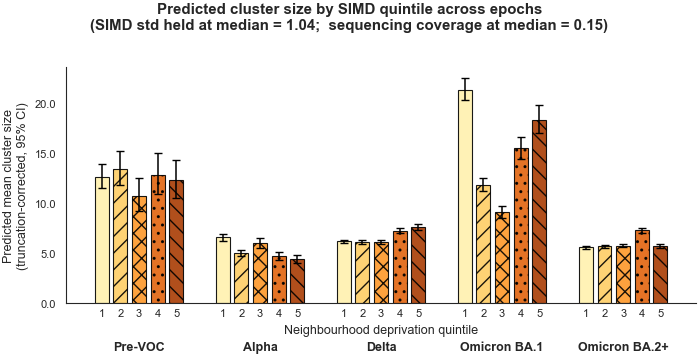

Marginal effects plot saved.


In [5]:
plot_marginal_effects(model_data, result)

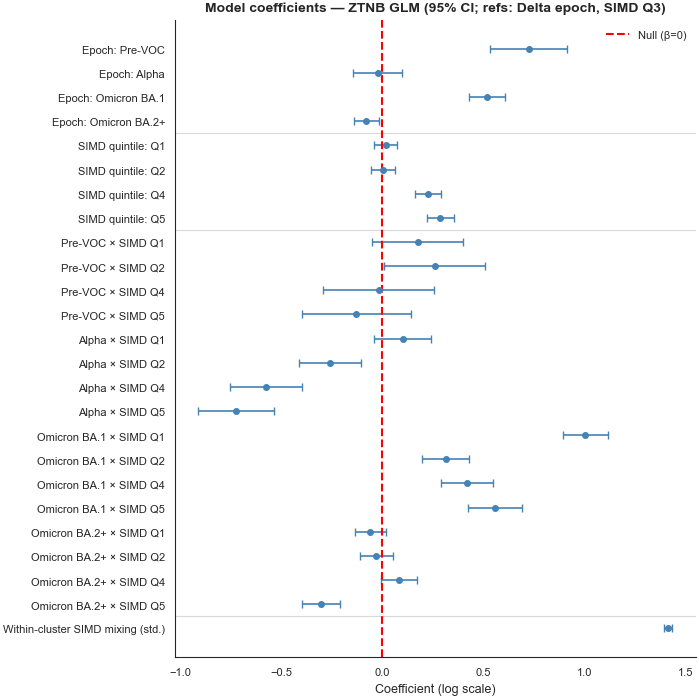

Forest plot saved.


In [6]:
plot_forest(result, X_df)

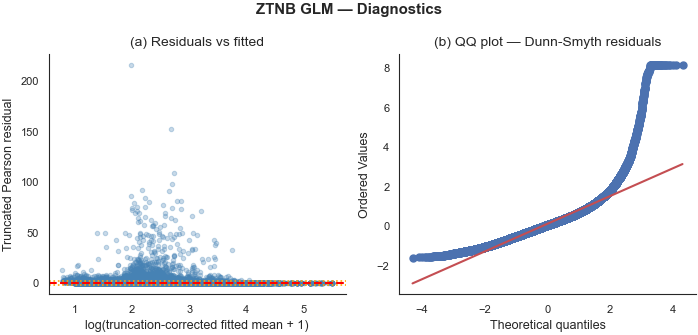

Diagnostic plots saved.


In [19]:
plot_diagnostics(model_data, result, X_df)

In [7]:
betainc